# 🚀 Missão Aurora Siger — Relatório Operacional de Pré-Decolagem

**Atividade integradora:** Ciência da Computação · Pensamento Computacional (Python) · IA & Prompt Engineering · Energias Renováveis e Sustentáveis · Formação Social e Sustentabilidade

**Grupo 18:** Felipe de Barros Franco, Guilherme Santos

**Objetivo:** consolidar as verificações técnicas, energéticas e éticas necessárias para autorizar (ou não) a decolagem da nave **Aurora Siger**.

Este notebook segue os itens da atividade integradora e reproduz, célula a célula, a mesma lógica publicada em `service.py` e `main.py` no repositório:

1. [1.1 Organização e descrição da telemetria](#1.1)
2. [1.2 Algoritmo de verificação](#1.2)
3. [1.3 Script em Python](#1.3)
4. [1.4 Análise energética](#1.4)
5. [1.5 Análise assistida por IA](#1.5)
6. [1.6 Reflexão crítica](#1.6)

> No repositório, `main.py` lê a telemetria com `input()`, direto do terminal. Aqui no notebook, os mesmos valores são atribuídos diretamente às variáveis (para não travar a execução esperando entrada do usuário), mas a lógica chamada em seguida — `pre_decolagem()` e `decolagem()` — é exatamente a de `service.py`, sem nenhuma alteração.

<a id="1.1"></a>
## 1.1 Organização e descrição da telemetria

A tabela abaixo descreve cada parâmetro monitorado pelos sensores da nave, sua unidade e a faixa considerada segura — as mesmas faixas usadas pelo algoritmo de verificação do item 1.2:

| Parâmetro | Unidade | Faixa segura | Descrição |
|---|---|---|---|
| Temperatura interna | °C | 18,0 a 27,0 | Temperatura da cabine e da eletrônica embarcada |
| Temperatura externa | °C | -60,0 a 45,0 | Temperatura do casco e do ambiente externo |
| Integridade estrutural | booleano (0/1) | deve ser 1 | Indica se o casco e as junções estão íntegros |
| Nível de energia | % | mínimo 40,0 | Carga atual da bateria principal |
| Pressão do tanque | bar | 150,0 a 200,0 | Pressurização do propelente, lida como uma única leitura agregada |
| Status dos módulos críticos | booleano agregado (0/1) | deve ser 1 | Indica, em uma única leitura, se todos os módulos críticos estão operacionais |

Em `main.py`, esses seis valores chegam via `input()`. Para testar o algoritmo nas duas direções de decisão, dois cenários são reproduzidos abaixo: um **nominal** (tudo dentro da faixa) e um **com falhas** (para comprovar o caminho de bloqueio).

In [ ]:
# Em main.py, estes valores vêm de input(). Aqui, atribuídos diretamente
# para permitir executar o notebook de ponta a ponta sem interação manual.

# Cenário 1 — nominal (todos os parâmetros dentro da faixa segura)
telemetria_nominal = {
    "temp_interna": 21.5,
    "temp_externa": -42.3,
    "integridade": 1,
    "pressao_tanque": 182.0,
    "modulos_criticos": 1,
    "carga_atual": 87,
    "perdas": 6,
}

# Cenário 2 — com falhas (para validar o ramo de bloqueio do algoritmo)
telemetria_falha = {
    "temp_interna": 29.8,
    "temp_externa": -41.0,
    "integridade": 1,
    "pressao_tanque": 141.0,
    "modulos_criticos": 0,
    "carga_atual": 33,
    "perdas": 6,
}

import pandas as pd
pd.DataFrame([telemetria_nominal, telemetria_falha], index=["Cenário nominal", "Cenário com falhas"])

,temp_interna,temp_externa,integridade,pressao_tanque,modulos_criticos,carga_atual,perdas
Cenário nominal,21.5,-42.3,1,182.0,1,87,6
Cenário com falhas,29.8,-41.0,1,141.0,0,33,6


<a id="1.2"></a>
## 1.2 Algoritmo de verificação

**Pseudocódigo:**

```
INÍCIO
LER temp_interna, temp_externa, integridade, nivel_energia,
    pressao_tanque, modulos_criticos

falhas <- lista vazia

SE temp_interna NÃO ESTÁ ENTRE 18.0 E 27.0 ENTÃO
    ADICIONAR falha "temperatura interna fora da faixa"

SE temp_externa NÃO ESTÁ ENTRE -60.0 E 45.0 ENTÃO
    ADICIONAR falha "temperatura externa fora da faixa"

SE integridade != 1 ENTÃO
    ADICIONAR falha "integridade estrutural comprometida"

SE nivel_energia < 40.0 ENTÃO
    ADICIONAR falha "energia insuficiente"

SE pressao_tanque NÃO ESTÁ ENTRE 150.0 E 200.0 ENTÃO
    ADICIONAR falha "pressão do tanque fora da faixa"

SE modulos_criticos != 1 ENTÃO
    ADICIONAR falha "um ou mais módulos críticos com falha"

SE falhas está vazia ENTÃO
    status <- "DECOLAGEM AUTORIZADA"
SENÃO
    status <- "DECOLAGEM NÃO AUTORIZADA"

IMPRIMIR status
IMPRIMIR falhas (se houver)
FIM
```

O algoritmo testa **todos** os parâmetros antes de decidir — não interrompe na primeira falha. Isso custa o mesmo em tempo de execução e entrega, de uma vez, a lista completa do que precisa ser corrigido antes de uma nova tentativa.

**Fluxograma equivalente:**

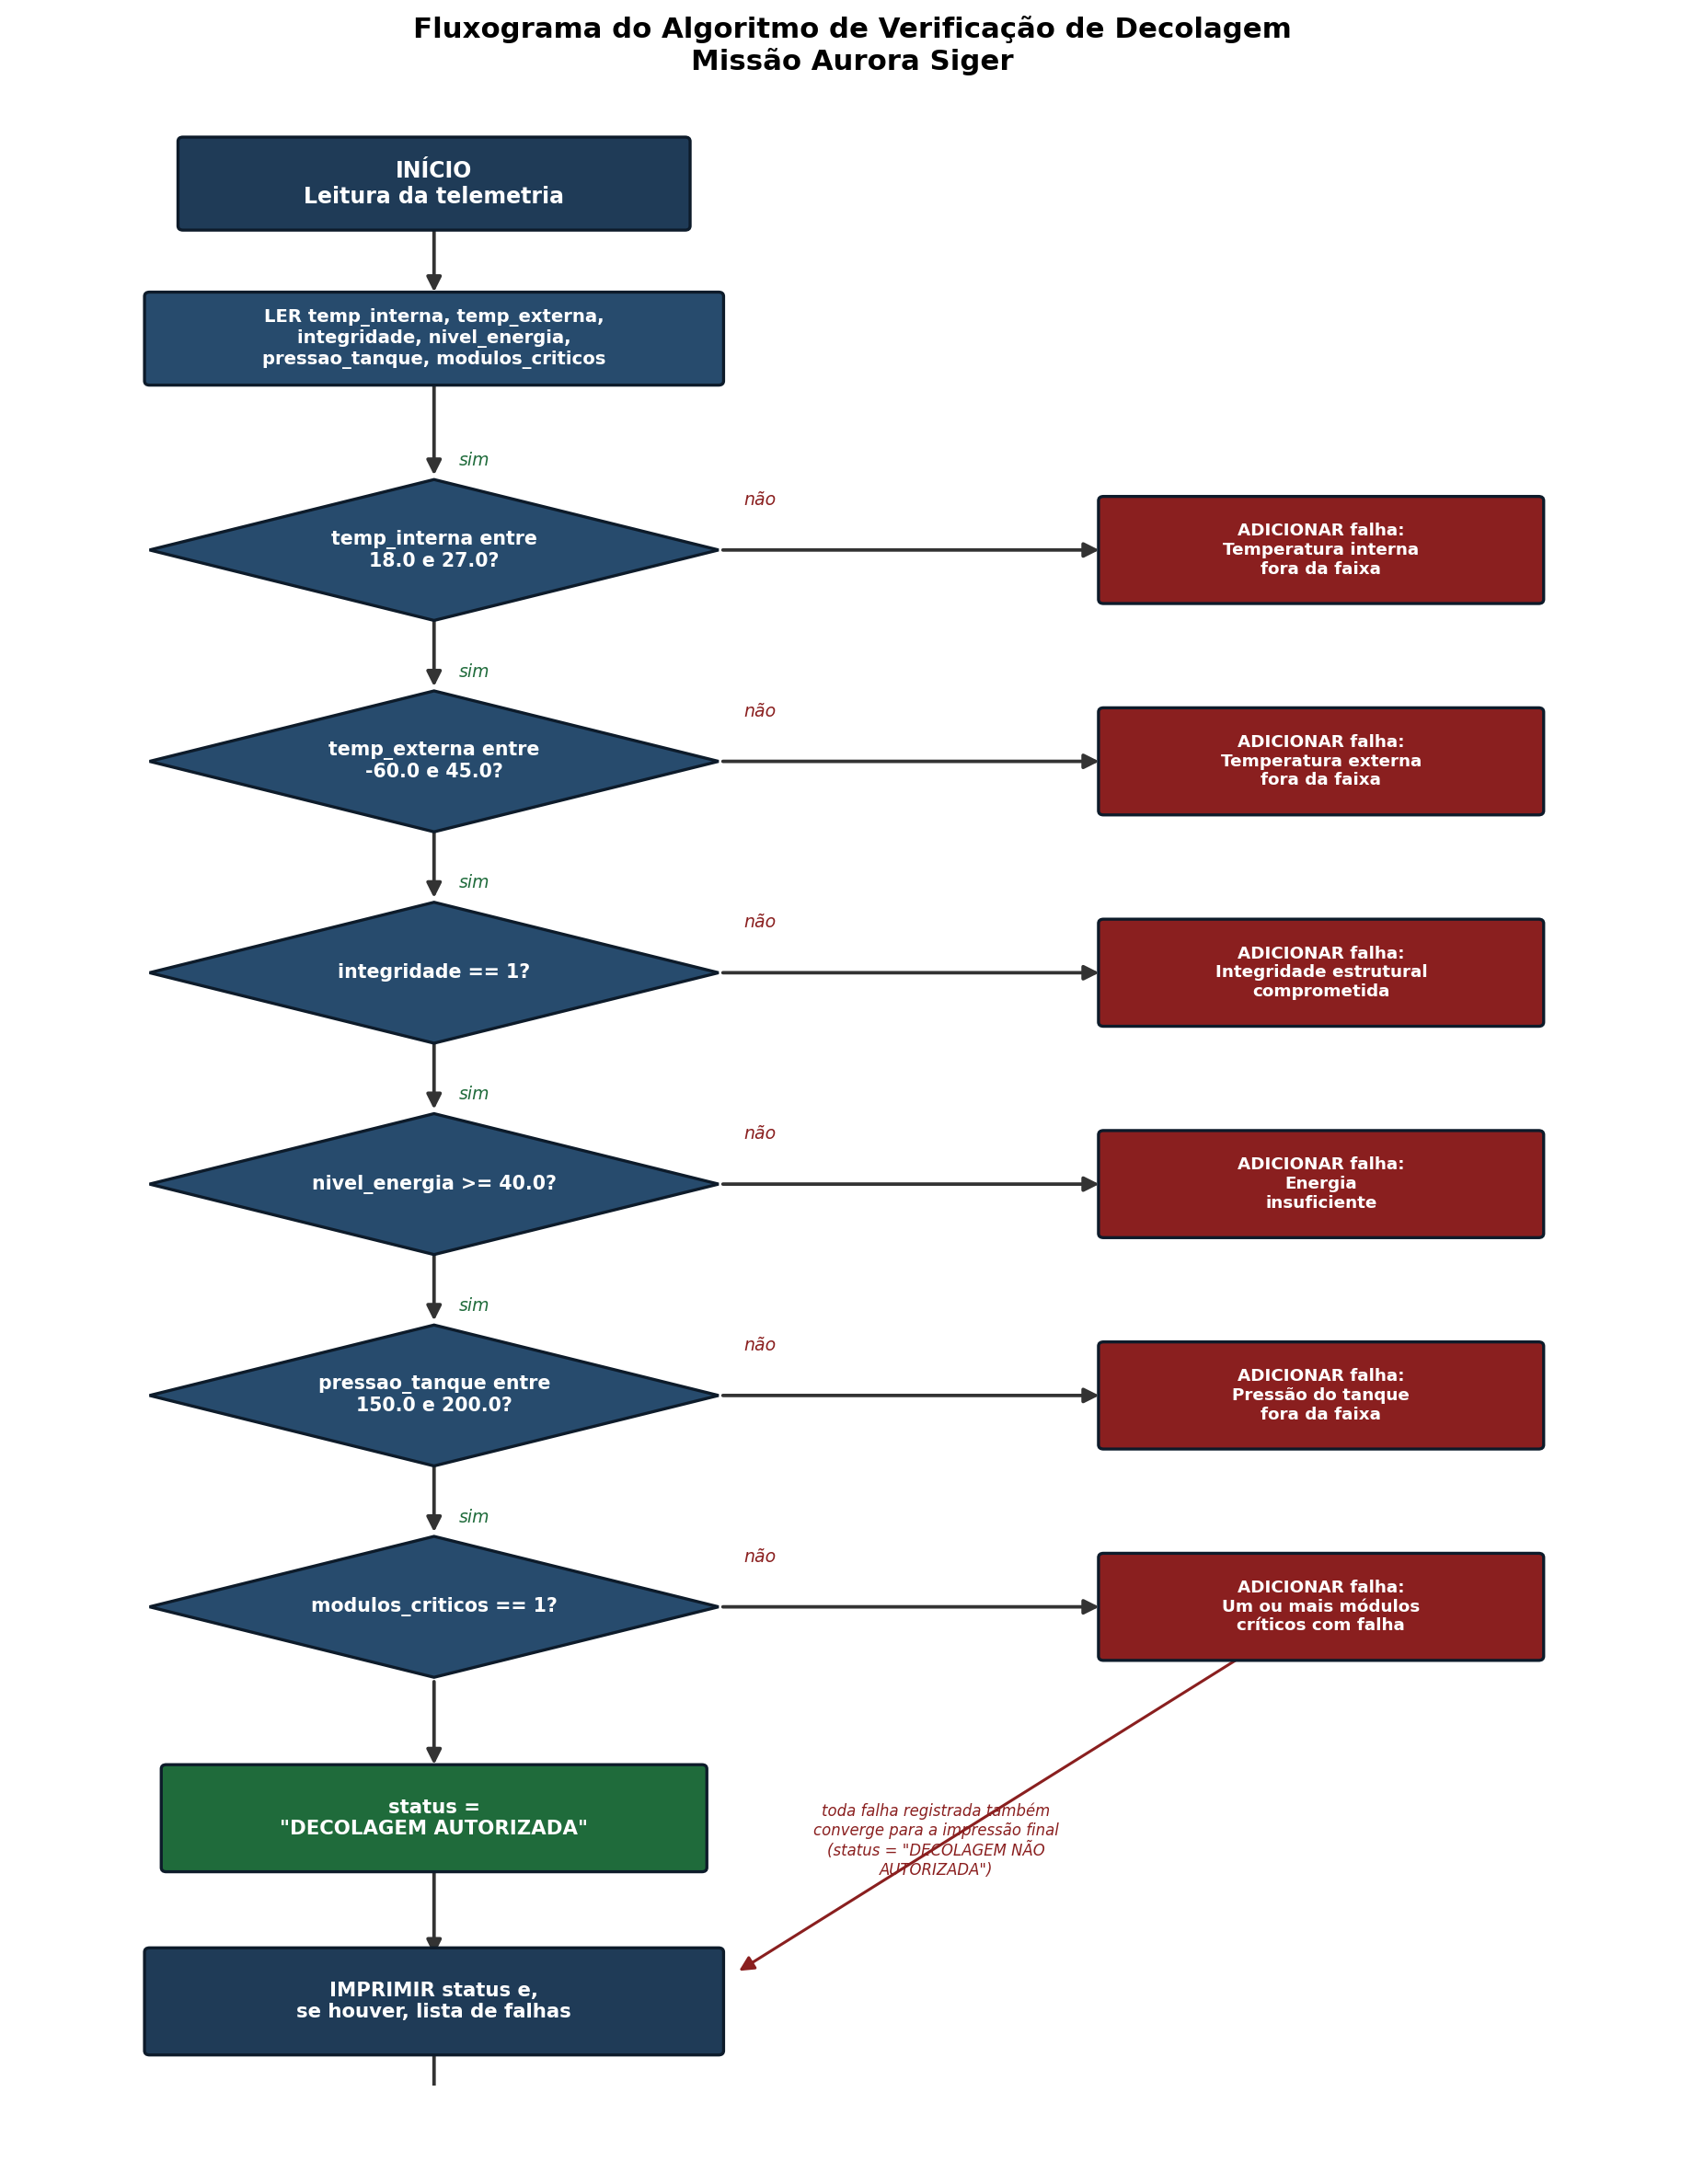

In [ ]:
from IPython.display import Image, display
display(Image(filename="imagens/fluxograma_verificacao.png", width=520))

<a id="1.3"></a>
## 1.3 Script em Python

O algoritmo é implementado em dois arquivos com responsabilidades separadas:

- **`service.py`** — as seis funções de verificação, mais `pre_decolagem()` (que as chama e reúne os erros) e `decolagem()` (que imprime o veredito). Nenhuma delas lê nem escreve em variável fora de si mesma.
- **`main.py`** — lê a telemetria com `input()`, calcula a análise energética, imprime as tabelas de saída e chama `pre_decolagem()` / `decolagem()`.

As células abaixo reproduzem `service.py` exatamente como publicado no repositório.

In [ ]:
# Verifica se a Temperatura Interna está dentro da faixa segura (18–27°C).
def verificar_temperatura_interna(temp_interna):
    print("Verificação de temperatura interna iniciada.")
    if 18.0 <= temp_interna <= 27.0:
        print("Temperatura interna válida!")
        return True, None
    print("Temperatura interna inválida!")
    return False, f"Temperatura interna fora da faixa segura: {temp_interna}°C (esperado 18.0–27.0)"


# Verifica se a Temperatura Externa está dentro da faixa segura (-60 a 45°C)
def verificar_temperatura_externa(temp_externa):
    print("Verificação de temperatura externa iniciada.")
    if -60.0 <= temp_externa <= 45.0:
        print("Temperatura externa válida!")
        return True, None
    print("Temperatura externa inválida!")
    return False, f"Temperatura externa fora da faixa segura: {temp_externa}°C (esperado -60.0–45.0)"


# Verifica se o casco e as junções Estruturais estão Íntegros
def verificar_integridade_estrutural(integridade):
    print("Verificação de integridade estrutural iniciada.")
    if integridade == 1:
        print("Integridade estrutural válida!")
        return True, None
    print("Integridade estrutural inválida!")
    return False, "Integridade estrutural comprometida (sensor reportou 0)"


# Verifica se o Nível de Energia é suficiente para decolagem (mínimo 40%)
def verificar_nivel_energia(nivel_energia):
    print("Verificação de nível de energia iniciada.")
    if nivel_energia >= 40.0:
        print("Nível de energia válido!")
        return True, None
    print("Nível de energia insuficiente!")
    return False, f"Nível de energia insuficiente: {nivel_energia}% (mínimo exigido: 40%)"


# Verifica se a Pressão do tanque está dentro da faixa segura (150–200 bar)
def verificar_pressao_tanque(pressao):
    print("Verificação de pressão do tanque iniciada.")
    if 150.0 <= pressao <= 200.0:
        print("Pressão do tanque válida!")
        return True, None
    print("Pressão do tanque inválida!")
    return False, f"Pressão do tanque fora da faixa segura: {pressao} bar (esperado 150–200)"


# Verifica se todos os Módulos Críticos estão operacionais
def verificar_modulos_criticos(modulos_criticos):
    print("Verificação dos módulos críticos iniciada.")
    if modulos_criticos == 1:
        print("Módulos críticos válidos!")
        return True, None
    print("Um ou mais módulos críticos com falha!")
    return False, "Um ou mais módulos críticos com falha"


# Orquestra todas as verificações e reúne os erros encontrados em uma lista
def pre_decolagem(temp_interna, temp_externa, integridade, nivel_energia, pressao_tanque, modulos_criticos):
    """ Executa todas as verificações de pré-decolagem e devolve a lista de erros
    encontrados (vazia se estiver tudo certo). Recebe tudo que precisa como parâmetro
    e devolve tudo que produz, sem variável global. """

    resultados = [
        verificar_temperatura_interna(temp_interna),
        verificar_temperatura_externa(temp_externa),
        verificar_integridade_estrutural(integridade),
        verificar_nivel_energia(nivel_energia),
        verificar_pressao_tanque(pressao_tanque),
        verificar_modulos_criticos(modulos_criticos),
    ]

    erros = []
    for valido, mensagem_erro in resultados:
        if not valido:
            erros.append(mensagem_erro)
    return erros


# Imprime o veredito final (autorizada ou não) a partir da lista de erros
def decolagem(erros):
    print("\n" + "=" * 80)
    if not erros:
        print("DECOLAGEM AUTORIZADA")
    else:
        print("DECOLAGEM NÃO AUTORIZADA, VEJA OS ERROS!")
        print("=" * 80)
        for erro in erros:
            print(erro)
    print("=" * 80)

In [ ]:
print("### CENÁRIO 1: TELEMETRIA NOMINAL ###\n")
erros_nominal = pre_decolagem(
    temp_interna=telemetria_nominal["temp_interna"],
    temp_externa=telemetria_nominal["temp_externa"],
    integridade=telemetria_nominal["integridade"],
    nivel_energia=telemetria_nominal["carga_atual"],
    pressao_tanque=telemetria_nominal["pressao_tanque"],
    modulos_criticos=telemetria_nominal["modulos_criticos"],
)
decolagem(erros_nominal)

### CENÁRIO 1: TELEMETRIA NOMINAL ###

Verificação de temperatura interna iniciada.
Temperatura interna válida!
Verificação de temperatura externa iniciada.
Temperatura externa válida!
Verificação de integridade estrutural iniciada.
Integridade estrutural válida!
Verificação de nível de energia iniciada.
Nível de energia válido!
Verificação de pressão do tanque iniciada.
Pressão do tanque válida!
Verificação dos módulos críticos iniciada.
Módulos críticos válidos!

DECOLAGEM AUTORIZADA


In [ ]:
print("### CENÁRIO 2: TELEMETRIA COM FALHAS ###\n")
erros_falha = pre_decolagem(
    temp_interna=telemetria_falha["temp_interna"],
    temp_externa=telemetria_falha["temp_externa"],
    integridade=telemetria_falha["integridade"],
    nivel_energia=telemetria_falha["carga_atual"],
    pressao_tanque=telemetria_falha["pressao_tanque"],
    modulos_criticos=telemetria_falha["modulos_criticos"],
)
decolagem(erros_falha)

### CENÁRIO 2: TELEMETRIA COM FALHAS ###

Verificação de temperatura interna iniciada.
Temperatura interna inválida!
Verificação de temperatura externa iniciada.
Temperatura externa válida!
Verificação de integridade estrutural iniciada.
Integridade estrutural válida!
Verificação de nível de energia iniciada.
Nível de energia insuficiente!
Verificação de pressão do tanque iniciada.
Pressão do tanque inválida!
Verificação dos módulos críticos iniciada.
Um ou mais módulos críticos com falha!

DECOLAGEM NÃO AUTORIZADA, VEJA OS ERROS!
Temperatura interna fora da faixa segura: 29.8°C (esperado 18.0–27.0)
Nível de energia insuficiente: 33% (mínimo exigido: 40%)
Pressão do tanque fora da faixa segura: 141.0 bar (esperado 150–200)
Um ou mais módulos críticos com falha


<a id="1.4"></a>
## 1.4 Análise energética

A autonomia inicial é calculada em quatro passos, exatamente como em `main.py`:

$$E_{disponível} = C_{total} \times \dfrac{Carga\%}{100}$$

$$E_{perdida} = E_{disponível} \times \dfrac{Perdas\%}{100}$$

$$E_{útil} = E_{disponível} - E_{perdida}$$

$$E_{restante} = E_{útil} - Consumo_{decolagem}$$

Onde `capacidade_total` (150 kWh) e `consumo_decolagem` (30 kWh) são constantes de engenharia definidas em `main.py`, e `carga_atual` / `perdas` vêm da telemetria.

In [ ]:
def calcular_energia(capacidade_total, carga_atual, perdas, consumo_decolagem):
    energia_disponivel = capacidade_total * (carga_atual / 100)
    energia_perdida = energia_disponivel * (perdas / 100)
    energia_util = energia_disponivel - energia_perdida
    energia_restante = energia_util - consumo_decolagem
    return {
        "capacidade_total": capacidade_total,
        "carga_atual": carga_atual,
        "energia_disponivel": round(energia_disponivel, 2),
        "perdas": perdas,
        "energia_perdida": round(energia_perdida, 2),
        "energia_util": round(energia_util, 2),
        "consumo_decolagem": consumo_decolagem,
        "energia_restante": round(energia_restante, 2),
    }


def imprimir_analise_energetica(r):
    print("ANÁLISE ENERGÉTICA")
    print("-" * 80)
    print(f"Capacidade total da bateria.............: {r['capacidade_total']:.1f} kWh")
    print(f"Carga atual (telemetria)................: {r['carga_atual']}%")
    print(f"Energia disponível.......................: {r['energia_disponivel']:.2f} kWh")
    print(f"Perdas energéticas ({r['perdas']}%)..................: {r['energia_perdida']:.2f} kWh")
    print(f"Energia útil (após perdas)...............: {r['energia_util']:.2f} kWh")
    print(f"Consumo estimado na decolagem............: {r['consumo_decolagem']:.2f} kWh")
    print(f"Energia restante pós-decolagem...........: {r['energia_restante']:.2f} kWh")
    print("=" * 80)


resultado_nominal = calcular_energia(
    capacidade_total=150, carga_atual=telemetria_nominal["carga_atual"],
    perdas=telemetria_nominal["perdas"], consumo_decolagem=30,
)
imprimir_analise_energetica(resultado_nominal)

ANÁLISE ENERGÉTICA
--------------------------------------------------------------------------------
Capacidade total da bateria.............: 150.0 kWh
Carga atual (telemetria)................: 87%
Energia disponível.......................: 130.50 kWh
Perdas energéticas (6%)..................: 7.83 kWh
Energia útil (após perdas)...............: 122.67 kWh
Consumo estimado na decolagem............: 30.00 kWh
Energia restante pós-decolagem...........: 92.67 kWh


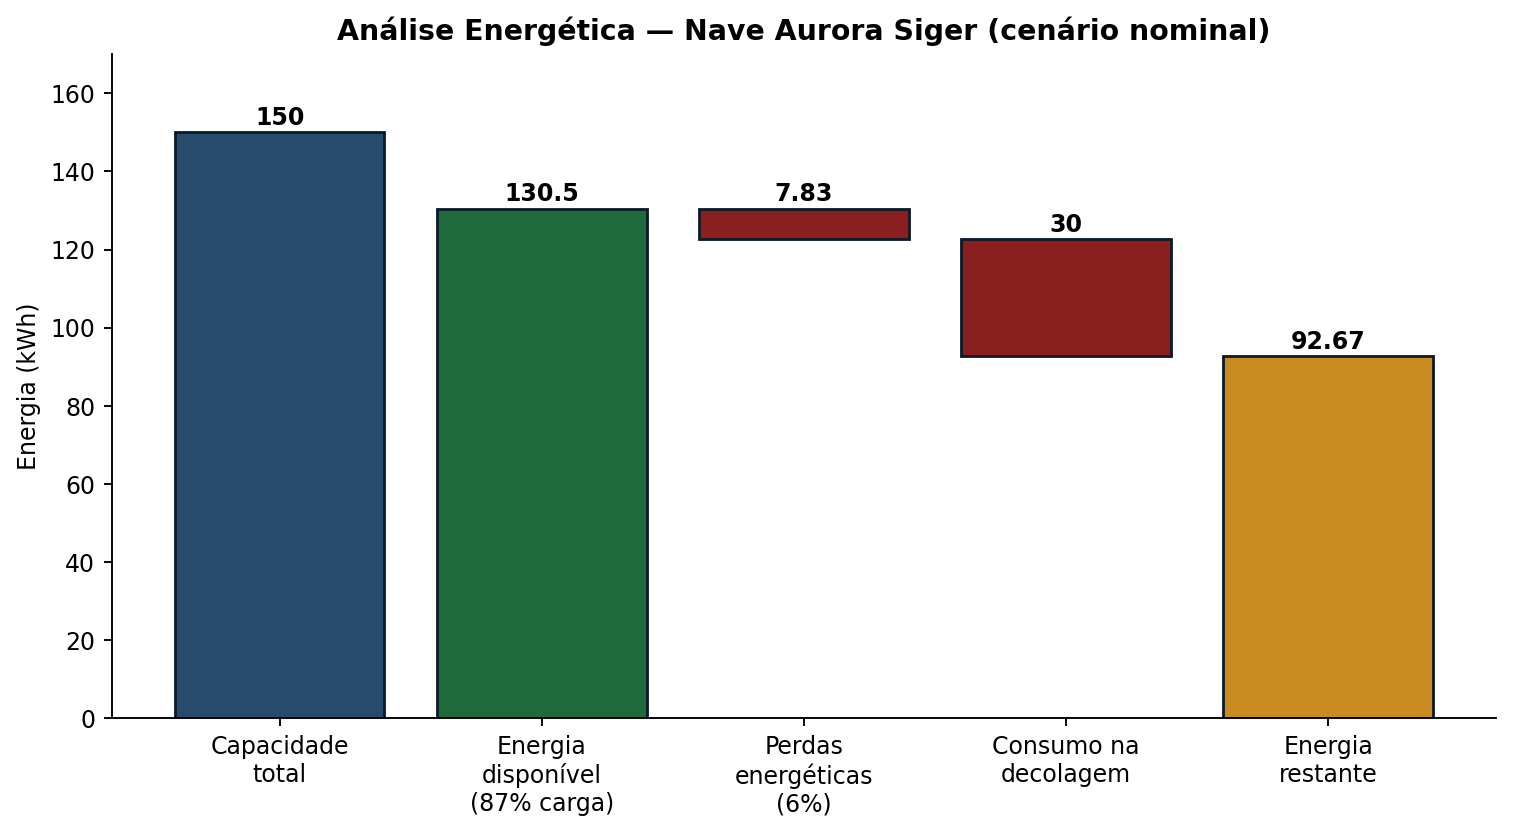

In [ ]:
display(Image(filename="imagens/analise_energetica.png", width=620))

**Leitura dos resultados:** com 87% de carga em uma bateria de 150 kWh, a nave dispõe de 130,5 kWh. Depois de 6% de perdas energéticas (7,83 kWh) e do consumo fixo de 30 kWh estimado para a decolagem, restam **92,67 kWh** para o restante da missão. Esse número — não uma estimativa de horas de autonomia — é o que `main.py` calcula e imprime; é ele que orienta a equipe de missão sobre quando recorrer a recarga ou a modos de economia de energia.

<a id="1.5"></a>
## 1.5 Análise assistida por IA

### 1.5.1 Classificação, anomalias e risco na telemetria

Os dois cenários de telemetria foram submetidos a um assistente com o seguinte prompt:

> *"Classifique cada parâmetro de telemetria como NOMINAL, ATENÇÃO ou CRÍTICO em relação às faixas seguras informadas, aponte quaisquer anomalias entre os parâmetros (não apenas violações isoladas de faixa) e sugira o nível de risco geral da decolagem com uma recomendação objetiva."*

**Resposta da IA — Cenário 1 (telemetria nominal):**

| Parâmetro | Valor | Classificação |
|---|---|---|
| Temperatura interna | 21,5 °C | 🟢 NOMINAL |
| Temperatura externa | -42,3 °C | 🟢 NOMINAL |
| Integridade estrutural | 1 | 🟢 NOMINAL |
| Nível de energia | 87% | 🟢 NOMINAL (margem confortável acima do mínimo de 40%) |
| Pressão do tanque | 182,0 bar | 🟢 NOMINAL |
| Módulos críticos | 1 (todos operacionais) | 🟢 NOMINAL |

*Anomalias identificadas:* nenhuma. Os seis parâmetros estão confortavelmente dentro da faixa, sem correlação que sugira problema latente.
*Sugestão de risco:* **BAIXO** — recomenda-se prosseguir com a contagem regressiva.

**Resposta da IA — Cenário 2 (telemetria com falhas):**

| Parâmetro | Valor | Classificação |
|---|---|---|
| Temperatura interna | 29,8 °C | 🔴 CRÍTICO (2,8 °C acima do limite) |
| Temperatura externa | -41,0 °C | 🟢 NOMINAL |
| Integridade estrutural | 1 | 🟢 NOMINAL |
| Nível de energia | 33% | 🔴 CRÍTICO (7 p.p. abaixo do mínimo) |
| Pressão do tanque | 141,0 bar | 🔴 CRÍTICO (9 bar abaixo do mínimo) |
| Módulos críticos | 0 (ao menos um em falha) | 🔴 CRÍTICO |

*Anomalias identificadas além das violações isoladas de faixa:*
1. **Temperatura alta + energia baixa:** a combinação sugere sobrecarga ou falha no sistema de refrigeração, que também consome energia — recomenda-se inspecionar o subsistema térmico.
2. **Queda de pressão simultânea à falha de módulo crítico:** mais consistente com uma falha real de propulsão/pressurização do que com duas leituras de sensor independentes e coincidentes.

*Sugestão de risco:* **ALTO** — recomenda-se abortar a decolagem, isolar o subsistema de propulsão e o tanque para inspeção, e repetir a checagem completa antes da próxima janela.

> 💡 A IA entra aqui como camada de apoio à decisão, não como substituta do algoritmo determinístico dos itens 1.2/1.3: o algoritmo responde sempre da mesma forma para a mesma entrada (o que se espera de um sistema de segurança), e a IA acrescenta uma leitura qualitativa que cruza parâmetros, algo que regras de faixa isoladas não fazem sozinhas. Cada sugestão só foi incorporada depois de entendida, revisada e testada.

Essa forma de trabalhar é detalhada no `README.md` do repositório.

<a id="1.6"></a>
## 1.6 Reflexão crítica

**Ética e responsabilidade.** Automatizar a decisão entre autorizar e bloquear uma decolagem coloca no código uma responsabilidade que, numa missão real, envolve vidas e recursos de altíssimo valor. As faixas seguras precisam vir de critério de engenharia, não de conveniência, e o sistema precisa ser auditável — por isso o algoritmo registra cada não conformidade separadamente, em vez de devolver só um "sim" ou "não". A IA do item 1.5 exige o mesmo cuidado: ela pode identificar padrões úteis, mas também pode errar com aparência de análise técnica, então suas sugestões apoiam a decisão humana sem substituir a verificação determinística.

**Impacto social da exploração espacial.** Missões como a Aurora Siger dependem de investimento alto em ciência, engenharia e formação especializada — recurso que poderia, em parte, ir para problemas terrestres imediatos como saneamento, saúde e educação. Por outro lado, tecnologias nascidas da exploração espacial costumam voltar à sociedade em usos civis (sensores miniaturizados, purificação de água, materiais mais leves, algoritmos de decisão autônoma). O ponto crítico é quem fica com esse retorno: concentrado em poucas empresas ou países, ele aprofunda desigualdades já existentes em vez de reduzi-las.

**Sustentabilidade tecnológica.** A análise do item 1.4 mostra, em escala pequena, algo válido para qualquer sistema computacional: a energia disponível é finita e conhecida. Numa nave isso é óbvio — a bateria tem capacidade fixa e não há recarga no meio do caminho. Escrever algoritmos eficientes é, então, mais que boa prática de engenharia: cada joule economizado em processamento é um joule que não precisou ser gerado, transmitido e armazenado, cada etapa com sua própria perda. O mesmo raciocínio vale para o projeto aeroespacial como um todo — geração renovável embarcada e controle de resíduos orbitais funcionam melhor como requisito desde o início do que como ajuste posterior.

---
## ✅ Conclusão

Este notebook consolidou o relatório operacional de pré-decolagem da missão **Aurora Siger** no estado atual do projeto: telemetria com valores agregados (um tanque, um indicador de módulos críticos), algoritmo implementado em `service.py`/`main.py` e testado nos dois cenários de decisão, energia restante pós-decolagem calculada em 92,67 kWh para o cenário nominal, análise assistida por IA sobre a telemetria e sobre o próprio processo de desenvolvimento, e a reflexão crítica exigida pela atividade.

**Repositório e instruções completas de execução:** ver `README.md`.
